In [66]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## KernelDensity Estimation for Foreground Detectio

### 1.1 Image Preprocessing

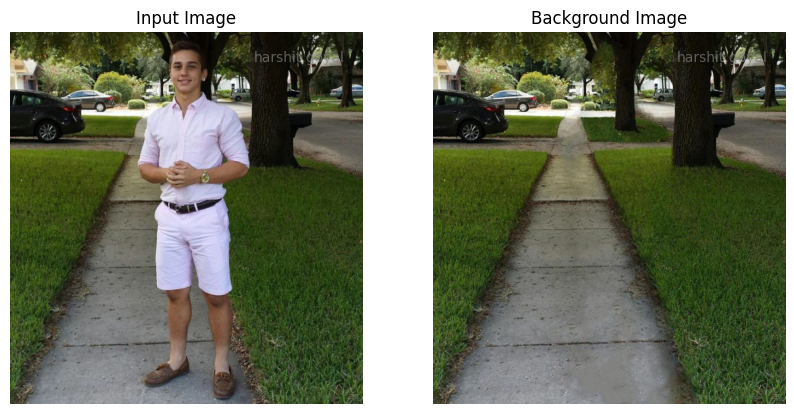

((571, 540, 3), (571, 540, 3))

In [ ]:
img = cv2.imread('./Dataset/Q1/Full.jpg')
bg = cv2.imread('./Dataset/Q1/back.jpg')

# img.shape, bg.shape

w,h = bg.shape[:2]
img = cv2.resize(img, (h,w),interpolation=cv2.INTER_AREA)

plt.figure(figsize=(10,10))
plt.subplot(121),  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.axis('off'), plt.title('Input Image')
plt.text(0.95, 0.95, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
plt.subplot(122),  plt.imshow(cv2.cvtColor(bg, cv2.COLOR_BGR2RGB)), plt.axis('off'), plt.title('Background Image')
plt.text(0.95, 0.95, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
plt.show()

img.shape, bg.shape

In [68]:
def extract_features(image, mode="rgb", bins=16):

    img = image.astype(np.float32) / 255.0

    if mode == "gray":
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        features = gray.reshape(-1, 1)

    elif mode == "rgb":
        features = img.reshape(-1, 3)

    elif mode == "hsv":
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        features = hsv.reshape(-1, 3)

    elif mode == "lab":
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
        features = lab.reshape(-1, 3)

    elif mode == "hist":
        hist_features = []
        for i in range(3):
            hist = cv2.calcHist([image], [i], None, [bins], [0, 256])
            hist = cv2.normalize(hist, hist).flatten()
            hist_features.append(hist)
        features = np.hstack(hist_features).reshape(1, -1)  # single feature vector for whole image

    elif mode == "rgbxy":
        h, w, _ = img.shape
        X, Y = np.meshgrid(np.arange(w), np.arange(h))
        XY = np.stack((X / w, Y / h), axis=-1)  # normalize coordinates
        features = np.concatenate([img, XY], axis=-1).reshape(-1, 5)

    return features


In [69]:
fg_features = extract_features(img, mode="rgbxy")
bg_features = extract_features(bg, mode="rgbxy")

fg_features.shape, bg_features.shape

((308340, 5), (308340, 5))

### 1.2 Custom KDE Implementation

In [114]:
from torch import dist


class CustomKDE:
    def __init__(self, kernel="gaussian", bandwidth=0.1, data=None):
        """
        Initialize the KDE model.
        Parameters:
            kernel : str  -> 'gaussian', 'uniform', or 'triangular'
            bandwidth : float  -> smoothing parameter
            data : np.ndarray  -> training data (optional)
        """
        assert bandwidth > 0, "Bandwidth must be positive."
        self.kernel = kernel.lower()
        self.bandwidth = bandwidth
        self.data = None
        if data is not None:
            self.fit(data)
    
    def fit(self, data, sample_fraction=0.1, random_state=42):
        """
        Store training data and optionally subsample for efficiency.
        Parameters:
            data : np.ndarray of shape (n_samples, n_features)
            sample_fraction : float -> fraction of samples to retain
        """
        np.random.seed(random_state)
        n = data.shape[0]
        sample_size = int(n * sample_fraction)
        if sample_size < n:
            idx = np.random.choice(n, sample_size, replace=False)
            self.data = data[idx]
        else:
            self.data = data
        self.n, self.d = self.data.shape

    def _kernel_function(self, u):
        """
        Evaluate the chosen kernel function.
        u : np.ndarray of shape (..., d)
        Returns: kernel value for each row
        """
        if self.kernel == "gaussian":
            const = 1 / ((2 * np.pi) ** (self.d / 2))
            return const * np.exp(-0.5 * np.sum(u**2, axis=1))
        
        elif self.kernel == "uniform":
            mask = np.all(np.abs(u) <= 1, axis=1)
            return np.where(mask, 0.5 ** self.d, 0.0)
        
        elif self.kernel == "triangular":
            dist = np.linalg.norm(u, axis=1)
            return np.where(dist <= 1, 1 - dist, 0.0)
        else:
            raise ValueError(f"Unknown kernel type: {self.kernel}")

    def predict(self, samples, chunk_size=1000):
        """
        Estimate density at given sample points.
        Parameters:
            samples : np.ndarray of shape (m_samples, n_features)
            chunk_size : for memory efficiency
        Returns:
            densities : np.ndarray of shape (m_samples,)
        """
        assert self.data is not None, "Model not fitted. Call fit(data) first."
        m = samples.shape[0]
        densities = np.zeros(m)
        h = self.bandwidth

        # Compute in chunks to handle large data efficiently
        for start in range(0, m, chunk_size):
            end = min(start + chunk_size, m)
            X_chunk = samples[start:end]
            
            # Compute all pairwise (x - xi)/h
            diff = (X_chunk[:, None, :] - self.data[None, :, :]) / h  # shape (chunk, n, d)
            kernel_vals = self._kernel_function(diff.reshape(-1, self.d)).reshape(X_chunk.shape[0], -1)
            
            densities[start:end] = np.sum(kernel_vals, axis=1) / (self.n * (h ** self.d))
        
        return densities


### 1.3 Foreground Detection 

In [71]:
def silverman_bandwidth(x):
    x = np.asarray(x)
    n = len(x)
    std = np.std(x, ddof=1)
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    sigma = min(std, iqr / 1.34)
    h = 0.9 * sigma * n ** (-1/5)
    return h

In [128]:
bg_features = extract_features(bg, mode="rgbxy")
test_features = extract_features(img, mode="rgbxy")

[h1,h2,h3,h4,h5] = [silverman_bandwidth(bg_features[:,i]) for i in range(bg_features.shape[1])]
h = np.mean([h1,h2,h3,h4,h5]).round(4)

print(f"Calculated bandwidth h: {h}")

Calculated bandwidth h: 0.016


In [129]:
bandwidths_gaussian = [h, 0.02, 0.03, 0.05, 0.1]

gaussian_densities = {}

for bw in bandwidths_gaussian:
    print(f"\nTraining KDE: kernel=gaussian, bandwidth={bw}")
    
    kde = CustomKDE(kernel="gaussian", bandwidth=bw)
    kde.fit(bg_features, sample_fraction=0.015)
    
    densities = kde.predict(test_features)
    gaussian_densities[bw] = densities
    
    print("done.")


Training KDE: kernel=gaussian, bandwidth=0.016
done.

Training KDE: kernel=gaussian, bandwidth=0.02
done.

Training KDE: kernel=gaussian, bandwidth=0.03
done.

Training KDE: kernel=gaussian, bandwidth=0.05
done.

Training KDE: kernel=gaussian, bandwidth=0.1
done.


In [130]:
bandwidths_triangular = [0.3, 0.4, 0.5, 0.6]

triangular_densities = {}

for bw in bandwidths_triangular:
    print(f"\nTraining KDE: kernel=triangular, bandwidth={bw}")
    
    kde = CustomKDE(kernel="triangular", bandwidth=bw)
    kde.fit(bg_features, sample_fraction=0.015)
    
    densities = kde.predict(test_features)
    triangular_densities[bw] = densities
    
    print("done.")


Training KDE: kernel=triangular, bandwidth=0.3
done.

Training KDE: kernel=triangular, bandwidth=0.4
done.

Training KDE: kernel=triangular, bandwidth=0.5
done.

Training KDE: kernel=triangular, bandwidth=0.6
done.


In [131]:

uniform_bandwidths = [0.1,0.2, 0.3, 0.4]

uniform_densities = {}

for bw in uniform_bandwidths:
    print(f"\nTraining KDE: kernel=uniform, bandwidth={bw}")
    
    kde = CustomKDE(kernel="uniform", bandwidth=bw)
    kde.fit(bg_features, sample_fraction=0.015)
    
    densities = kde.predict(test_features)
    uniform_densities[bw] = densities 
    
    print("done.")



Training KDE: kernel=uniform, bandwidth=0.1
done.

Training KDE: kernel=uniform, bandwidth=0.2
done.

Training KDE: kernel=uniform, bandwidth=0.3
done.

Training KDE: kernel=uniform, bandwidth=0.4
done.


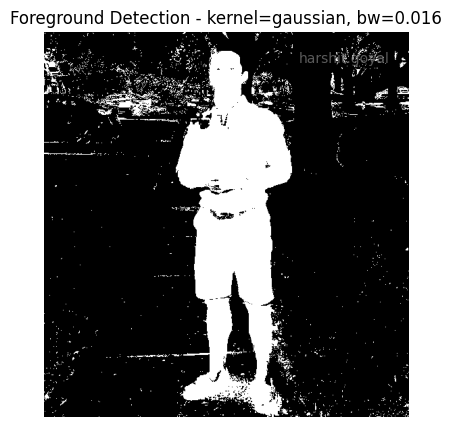

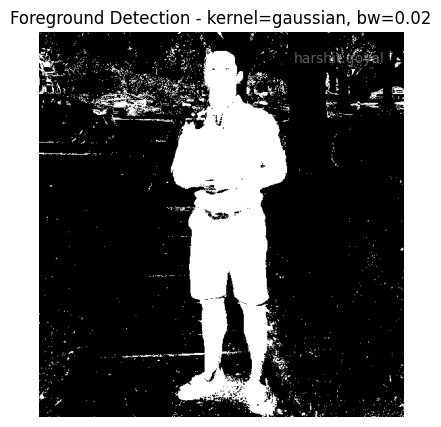

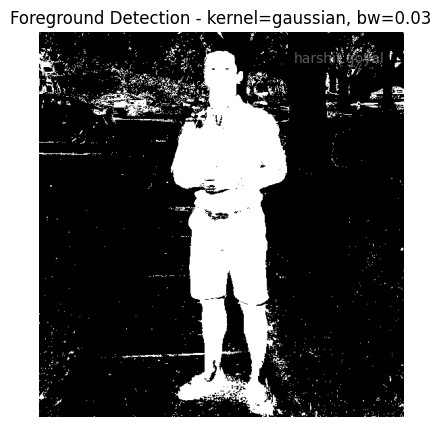

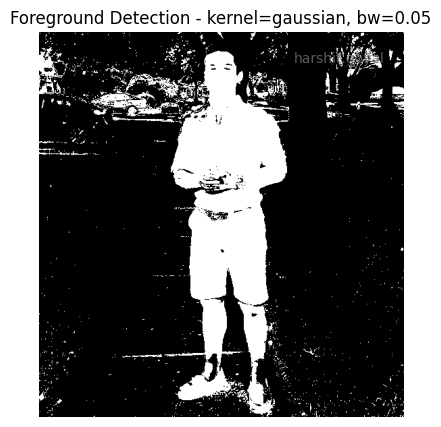

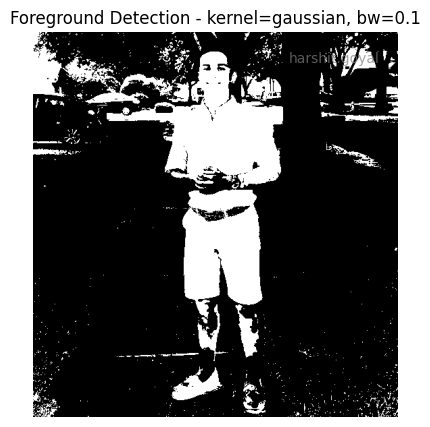

In [143]:
for bw, densities in gaussian_densities.items():

    threshold = np.percentile(densities, 19)
    mask = (densities < threshold).astype(np.uint8).reshape(img.shape[:2])

    plt.figure(figsize=(10, 5))
    plt.text(0.95, 0.95, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
    plt.imshow(mask, cmap='gray'), plt.title(f"Foreground Detection - kernel=gaussian, bw={bw}")
    plt.axis('off'), plt.show()


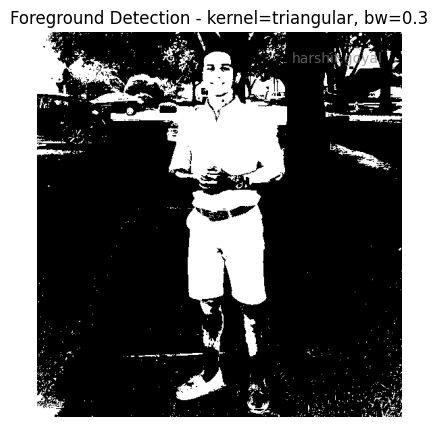

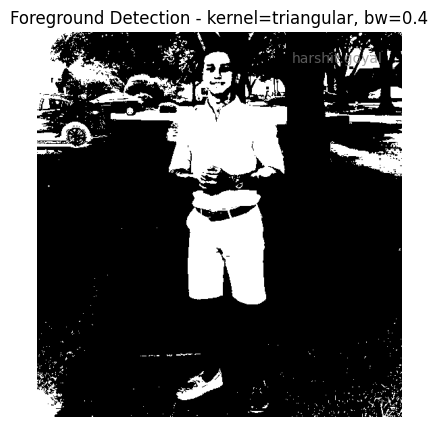

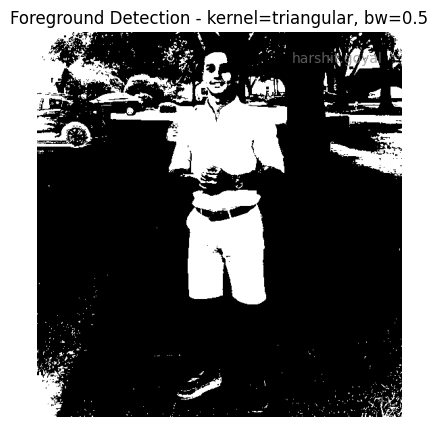

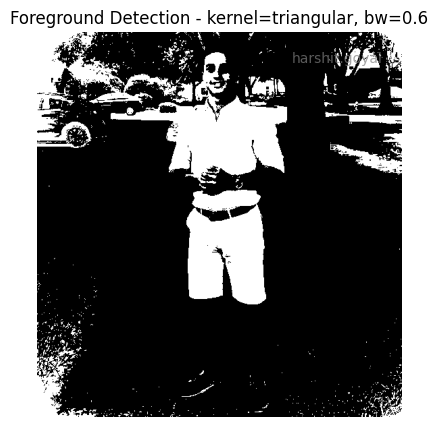

In [155]:
for bw, densities in triangular_densities.items():

    threshold = np.percentile(densities, 19)
    mask = (densities < threshold).astype(np.uint8).reshape(img.shape[:2])

    plt.figure(figsize=(10, 5))
    plt.text(0.95, 0.95, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
    plt.imshow(mask, cmap='gray'), plt.title(f"Foreground Detection - kernel=triangular, bw={bw}")
    plt.axis('off'), plt.show()


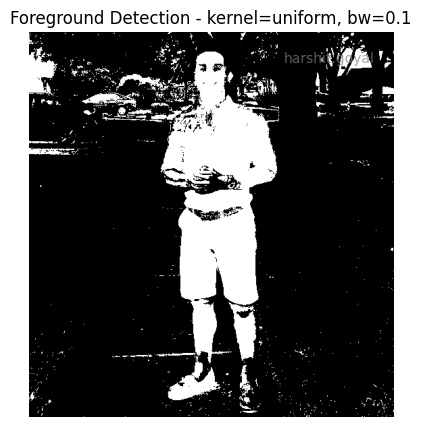

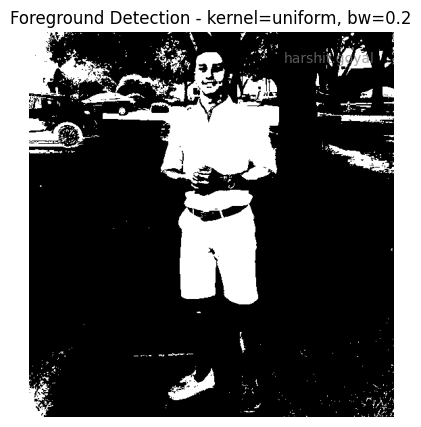

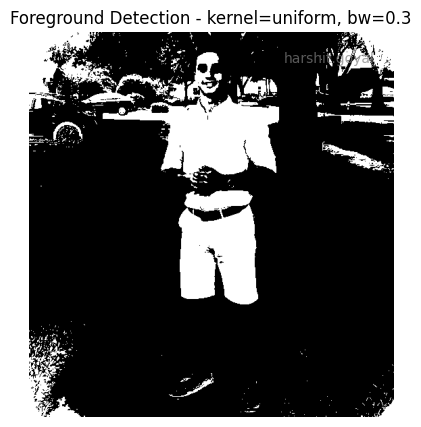

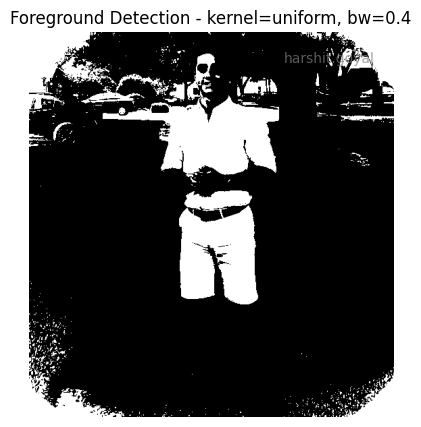

In [158]:
for bw, densities in uniform_densities.items():

    threshold = np.percentile(densities, 18)
    mask = (densities < threshold).astype(np.uint8).reshape(img.shape[:2])

    plt.figure(figsize=(10, 5))
    plt.text(0.95, 0.95, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
    plt.imshow(mask, cmap='gray'), plt.title(f"Foreground Detection - kernel=uniform, bw={bw}")
    plt.axis('off'), plt.show()


Best results obtained with:
- Kernel: Gaussian
- Bandwidth: 0.015
- Threshold Percentile: 19th percentile
- features: RGBXY values
